In [7]:
# === IMPORTS BÁSICOS E CONFIGURAÇÃO INICIAL ===

from pathlib import Path                     # Manipulação de caminhos de arquivos/pastas
import pandas as pd                           # Tabelas e manipulação de dados
import numpy as np                            # Utilidades numéricas
import fastf1                                 # API de dados de F1
from fastf1 import plotting                   # (opcional) utilidades extras do pacote

# === DEFINIÇÃO DE DIRETÓRIOS DO PROJETO ===
PROJ = Path.cwd().resolve().parent            # Diretório atual (raiz do projeto, se você abriu o notebook de lá)
DATA_DIR = PROJ / "data"                      # Pasta principal de dados
DATA_DIR.mkdir(exist_ok=True)                 # Garante que a pasta data exista
(DATA_DIR / "interim").mkdir(parents=True, exist_ok=True)   # Garante subpasta para dados intermediários

# === ATIVA CACHÊ LOCAL DO FASTF1 ===
CACHE_DIR = PROJ / "fastf1_cache"             # Pasta para cache do FastF1
CACHE_DIR.mkdir(exist_ok=True)                # Cria a pasta se não existir
fastf1.Cache.enable_cache(str(CACHE_DIR))     # Ativa o cache para acelerar chamadas futuras

# (opcional) estilos de plot do fastf1
plotting.setup_mpl(misc_mpl_mods=False)



c:\Users\pedro\iCloudDrive\Desktop\Eng. Elétrica UNESP Bauru 2020\TG\TG2\f1-tyre-strategy-simulator\.venv\Lib\site-packages\fastf1\plotting\_plotting.py:57: FutureWarning: The `misc_mpl_mods` argument was dropped from `.setup_mpl()` in version 3.6.0 and has no effect anymore. It will be removed in a future version of FastF1.
  warnings.warn(


In [8]:
# === FUNÇÕES AUXILIARES REUTILIZÁVEIS ===

def to_seconds(td):
    """Converte um pandas.Timedelta (ou NaT) para float em segundos."""
    return np.nan if pd.isna(td) else td.total_seconds()

def ensure_tyre_age(df: pd.DataFrame) -> pd.DataFrame:
    """Garante a coluna TyreLife; se ausente ou toda NaN, reconstrói por (Driver, Stint)."""
    df = df.copy()
    if "TyreLife" not in df.columns or df["TyreLife"].isna().all():
        # Ordena por piloto, stint e número da volta
        df = df.sort_values(["Driver", "Stint", "LapNumber"])
        # Conta cumulativamente as voltas dentro de cada stint (1,2,3,...)
        df["TyreLife"] = df.groupby(["Driver", "Stint"]).cumcount() + 1
    return df

def extract_event_laps(year: int, event_name: str) -> pd.DataFrame:
    """
    Extrai TODAS as voltas da CORRIDA (Race, 'R') para um (ano, evento) específico.
    Mantém in/out laps marcadas; converte tempos; agrega clima via merge_asof.
    Retorna um DataFrame pronto para concatenação posterior.
    """
    # Carrega a sessão de corrida do ano/evento usando FastF1
    session = fastf1.get_session(year, event_name, "R")
    session.load()  # Baixa dados (1ª vez) e usa cache nas próximas

    # Obtém todas as voltas como DataFrame
    laps = session.laps.reset_index(drop=True).copy()

    # Garante que colunas de pit existam mesmo se ausentes em alguma temporada
    for c in ["PitInTime", "PitOutTime"]:
        if c not in laps.columns:
            laps[c] = pd.NaT

    # Cria flags de in-lap/out-lap e uma flag agregada
    laps["IsPitInLap"]   = laps["PitInTime"].notna().astype(int)
    laps["IsPitOutLap"]  = laps["PitOutTime"].notna().astype(int)
    laps["IsInOrOutLap"] = (laps["IsPitInLap"] | laps["IsPitOutLap"]).astype(int)

    # Converte tempos de volta e setores para segundos mantendo o timedelta original
    for c in ["LapTime", "Sector1Time", "Sector2Time", "Sector3Time"]:
        if c in laps.columns:
            laps[c + "Sec"] = laps[c].apply(to_seconds)

    # Garante idade do pneu (TyreLife)
    laps = ensure_tyre_age(laps)

    # Adiciona metadados úteis
    laps["Year"] = year
    laps["EventName"] = event_name
    laps["Session"] = "Race"

    # Junta dados de clima da sessão (merge pelo tempo)
    weather = session.weather_data.copy()
    if weather is not None and not weather.empty and "Time" in weather.columns:
        # Alinha tipos para merge_asof (ambos como Timedelta)
        tmp = laps.copy()
        tmp["Time"] = pd.to_timedelta(tmp["Time"])
        weather["Time"] = pd.to_timedelta(weather["Time"])
        # Faz merge_asof pegando o valor de clima mais próximo no passado
        laps = pd.merge_asof(
            tmp.sort_values("Time"),
            weather[["Time","AirTemp","TrackTemp","Humidity","Pressure","WindSpeed","WindDirection"]].sort_values("Time"),
            on="Time", direction="backward"
        )

    # Ordena por piloto e volta para deixar o dataset “limpo”
    laps = laps.sort_values(["Driver", "LapNumber"]).reset_index(drop=True)
    return laps


In [9]:
# === ENTRADA DO USUÁRIO: INTERVALO DE ANOS E LISTAGEM DE CIRCUITOS ===

# Solicita ao usuário o ano inicial
year_start = int(input("Digite o ano INICIAL (ex.: 2018): ").strip())
# Solicita ao usuário o ano final
year_end   = int(input("Digite o ano FINAL   (ex.: 2024): ").strip())

# Garante que o intervalo esteja em ordem crescente
if year_end < year_start:
    year_start, year_end = year_end, year_start

# Cria uma lista de anos do intervalo (inclusive)
YEARS = list(range(year_start, year_end + 1))
print(f"Intervalo de anos selecionado: {YEARS}")

# Para descobrir quais eventos existem nesses anos, consultamos o calendário anual do FastF1
all_events = []                                 # Lista para acumular DataFrames de calendários
for y in YEARS:
    cal = fastf1.get_event_schedule(y, include_testing=False)  # Calendário oficial sem testes
    cal["Year"] = y                                           # Marca o ano no calendário
    all_events.append(cal[["Year","EventName","OfficialEventName","EventDate","Location"]])

# Concatena todos os calendários em um único DataFrame
events_df = pd.concat(all_events, ignore_index=True)

# Levanta a lista de eventos únicos que aparecem em pelo menos um dos anos
unique_events = sorted(events_df["EventName"].dropna().unique().tolist())

# Exibe uma lista enumerada para o usuário escolher o circuito
print("\n=== Circuitos com corridas válidas no intervalo ===")
for i, name in enumerate(unique_events, start=1):
    print(f"{i:2d}. {name}")

# Solicita ao usuário que escolha um índice da lista
idx = int(input("\nDigite o número do circuito desejado: ").strip())
# Valida o índice informado
if not (1 <= idx <= len(unique_events)):
    raise ValueError("Índice inválido. Rode novamente e escolha um número listado.")

# Obtém o nome do circuito selecionado
SELECTED_EVENT = unique_events[idx - 1]
print(f"\nVocê selecionou: {SELECTED_EVENT}")


Intervalo de anos selecionado: [2022, 2023, 2024]

=== Circuitos com corridas válidas no intervalo ===
 1. Abu Dhabi Grand Prix
 2. Australian Grand Prix
 3. Austrian Grand Prix
 4. Azerbaijan Grand Prix
 5. Bahrain Grand Prix
 6. Belgian Grand Prix
 7. British Grand Prix
 8. Canadian Grand Prix
 9. Chinese Grand Prix
10. Dutch Grand Prix
11. Emilia Romagna Grand Prix
12. French Grand Prix
13. Hungarian Grand Prix
14. Italian Grand Prix
15. Japanese Grand Prix
16. Las Vegas Grand Prix
17. Mexico City Grand Prix
18. Miami Grand Prix
19. Monaco Grand Prix
20. Qatar Grand Prix
21. Saudi Arabian Grand Prix
22. Singapore Grand Prix
23. Spanish Grand Prix
24. São Paulo Grand Prix
25. United States Grand Prix


C:\Users\pedro\AppData\Local\Temp\ipykernel_11448\2112252472.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cal["Year"] = y                                           # Marca o ano no calendário
C:\Users\pedro\AppData\Local\Temp\ipykernel_11448\2112252472.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cal["Year"] = y                                           # Marca o ano no calendário
C:\Users\pedro\AppData\Local\Temp\ipykernel_11448\2112252472.py:20: SettingWithCopyWarning: 
A value is trying t


Você selecionou: Singapore Grand Prix


In [10]:
# === EXTRAÇÃO EM LOTE: PARA CADA ANO DO INTERVALO, COLETA AS VOLTAS DO EVENTO ESCOLHIDO ===

all_laps_list = []                               # Lista para acumular os DataFrames de cada ano
errors = []                                       # Lista para registrar anos que por algum motivo falharam

for y in YEARS:
    try:
        # Tenta extrair as voltas do evento selecionado naquele ano
        df_year = extract_event_laps(y, SELECTED_EVENT)
        # Acrescenta o DataFrame obtido na lista
        all_laps_list.append(df_year)
        # Log simples de sucesso
        print(f"[OK] {SELECTED_EVENT} {y}: {len(df_year)} voltas extraídas.")
    except Exception as e:
        # Em caso de erro (evento pode não ter corrida em algum ano), registra e segue
        print(f"[ERRO] {SELECTED_EVENT} {y}: {e}")
        errors.append((y, str(e)))

# Concatena tudo em um único DataFrame (se houver pelo menos um sucesso)
if all_laps_list:
    laps_all_years = pd.concat(all_laps_list, ignore_index=True)
    print(f"\nTotal de voltas combinadas: {len(laps_all_years)}")
else:
    raise RuntimeError("Nenhuma corrida foi extraída. Verifique o intervalo e o circuito selecionado.")


core           INFO 	Loading data for Singapore Grand Prix - Race [v3.6.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No 

[OK] Singapore Grand Prix 2022: 945 voltas extraídas.


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

[OK] Singapore Grand Prix 2023: 1088 voltas extraídas.


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

[OK] Singapore Grand Prix 2024: 1177 voltas extraídas.

Total de voltas combinadas: 3210


In [11]:
# === SALVAMENTO DO DATASET COMBINADO ===

# Monta nomes de arquivos de saída com base nas escolhas do usuário
safe_event = SELECTED_EVENT.lower().replace(" ", "_")
out_csv = DATA_DIR / "interim" / f"{safe_event}_{year_start}-{year_end}_all_laps.csv"
out_parq = DATA_DIR / "interim" / f"{safe_event}_{year_start}-{year_end}_all_laps.parquet"

# Salva em CSV e Parquet
laps_all_years.to_csv(out_csv, index=False)
laps_all_years.to_parquet(out_parq, index=False)

# Mostra caminhos e uma amostra das colunas
print(f"CSV salvo em:     {out_csv}")
print(f"Parquet salvo em: {out_parq}")
display(laps_all_years.head(10))


CSV salvo em:     C:\Users\pedro\iCloudDrive\Desktop\Eng. Elétrica UNESP Bauru 2020\TG\TG2\f1-tyre-strategy-simulator\data\interim\singapore_grand_prix_2022-2024_all_laps.csv
Parquet salvo em: C:\Users\pedro\iCloudDrive\Desktop\Eng. Elétrica UNESP Bauru 2020\TG\TG2\f1-tyre-strategy-simulator\data\interim\singapore_grand_prix_2022-2024_all_laps.parquet


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,Sector3TimeSec,Year,EventName,Session,AirTemp,TrackTemp,Humidity,Pressure,WindSpeed,WindDirection
0,0 days 02:10:22.067000,ALB,23,0 days 00:02:25.330000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:58.058000,...,45.677,2022,Singapore Grand Prix,Race,26.8,29.5,82.0,1008.0,0.6,121
1,0 days 02:12:31.503000,ALB,23,0 days 00:02:09.436000,2.0,1.0,NaT,NaT,0 days 00:00:33.495000,0 days 00:00:51.192000,...,44.749,2022,Singapore Grand Prix,Race,26.9,29.9,82.0,1008.0,0.6,165
2,0 days 02:14:39.268000,ALB,23,0 days 00:02:07.765000,3.0,1.0,NaT,NaT,0 days 00:00:32.903000,0 days 00:00:50.410000,...,44.452,2022,Singapore Grand Prix,Race,26.9,29.8,82.0,1008.0,0.8,176
3,0 days 02:16:45.893000,ALB,23,0 days 00:02:06.625000,4.0,1.0,NaT,NaT,0 days 00:00:32.623000,0 days 00:00:49.859000,...,44.143,2022,Singapore Grand Prix,Race,26.8,29.4,82.0,1008.0,0.8,194
4,0 days 02:18:51.406000,ALB,23,0 days 00:02:05.513000,5.0,1.0,NaT,NaT,0 days 00:00:32.575000,0 days 00:00:49.553000,...,43.385,2022,Singapore Grand Prix,Race,26.9,29.3,83.0,1008.0,0.8,164
5,0 days 02:20:57.295000,ALB,23,0 days 00:02:05.889000,6.0,1.0,NaT,NaT,0 days 00:00:32.162000,0 days 00:00:50.170000,...,43.557,2022,Singapore Grand Prix,Race,27.0,29.4,83.0,1008.0,0.6,160
6,0 days 02:23:02.248000,ALB,23,0 days 00:02:04.953000,7.0,1.0,NaT,NaT,0 days 00:00:32.866000,0 days 00:00:49.190000,...,42.897,2022,Singapore Grand Prix,Race,27.0,29.4,82.0,1008.0,1.1,166
7,0 days 02:25:29.922000,ALB,23,0 days 00:02:27.674000,8.0,1.0,NaT,NaT,0 days 00:00:32.267000,0 days 00:01:03.196000,...,52.211,2022,Singapore Grand Prix,Race,27.1,28.8,83.0,1008.0,1.6,185
8,0 days 02:28:06.167000,ALB,23,NaT,9.0,1.0,NaT,NaT,0 days 00:00:44.108000,0 days 00:01:01.139000,...,50.994,2022,Singapore Grand Prix,Race,27.0,29.0,83.0,1008.0,1.0,180
9,0 days 02:30:33.928000,ALB,23,0 days 00:02:27.761000,10.0,1.0,NaT,NaT,0 days 00:00:35.227000,0 days 00:01:07.342000,...,45.192,2022,Singapore Grand Prix,Race,27.0,28.8,83.0,1008.0,0.5,0


count     mean    std      min      25%      50%      75%  \
Year Compound                                                              
2022 MEDIUM    210.0  115.195  8.783  108.165  110.544  112.154  115.302   
     SOFT       92.0  114.394  6.771  106.458  111.118  112.245  115.000   
2023 HARD      566.0  102.646  8.566   97.666   99.785  100.481  101.410   
     MEDIUM    409.0  101.091  4.811   95.867   99.626  100.562  101.196   
     SOFT       54.0   99.847  2.391   96.456   98.450   99.619  100.395   
2024 HARD      516.0   98.480  1.836   94.925   97.541   98.208   99.435   
     MEDIUM    520.0   99.169  1.687   96.495   98.359   98.909   99.488   
     SOFT       93.0   98.202  1.815   94.486   97.297   97.995   98.692   

                   max  
Year Compound           
2022 MEDIUM    149.586  
     SOFT      145.762  
2023 HARD      149.966  
     MEDIUM    137.522  
     SOFT      113.333  
2024 HARD      113.822  
     MEDIUM    111.981  
     SOFT      111.319

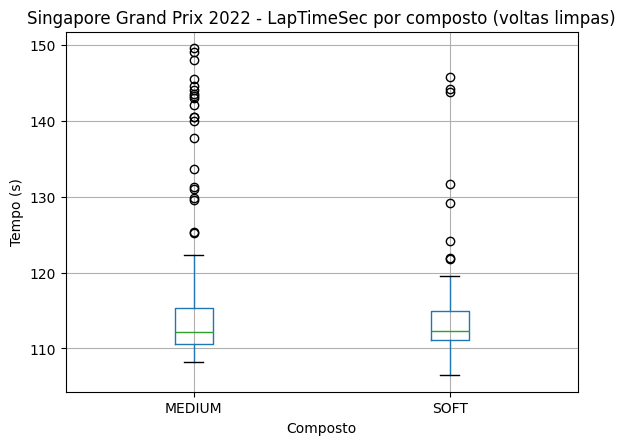

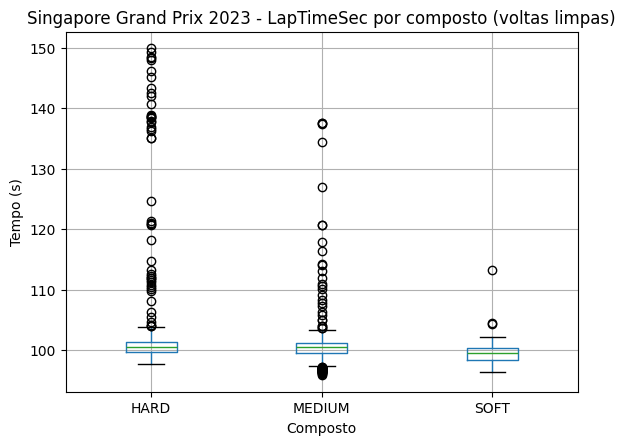

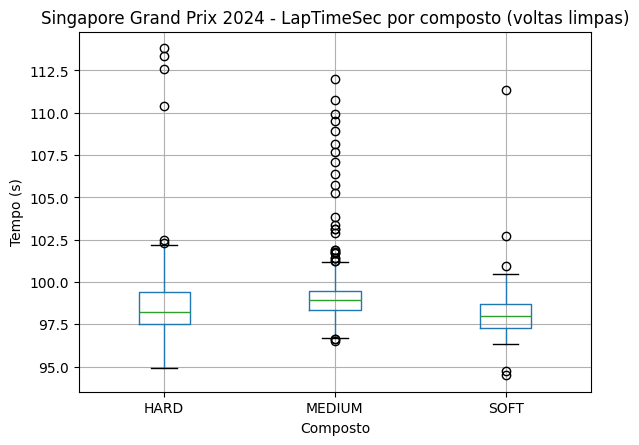

In [12]:
# === EDA RÁPIDA: VOLTAS LIMPAS E COMPOSTOS SECOS ===

# Cria um subconjunto removendo in/out laps para análise de ritmo
clean = laps_all_years[(laps_all_years["IsInOrOutLap"] == 0)].copy()

# Se quiser focar em pneus secos apenas:
if "Compound" in clean.columns:
    clean = clean[clean["Compound"].isin(["SOFT","MEDIUM","HARD"])]

# Estatísticas simples por ano e composto (se disponível)
if "Compound" in clean.columns:
    stats = (clean.groupby(["Year","Compound"])["LapTimeSec"]
                  .describe()[["count","mean","std","min","25%","50%","75%","max"]]
                  .round(3))
    display(stats.head(12))

# Boxplot simples (pode requerer muitos dados, ajuste se achar pesado)
import matplotlib.pyplot as plt
if "Compound" in clean.columns:
    for y in YEARS:
        subset = clean[clean["Year"] == y]
        if not subset.empty:
            subset.boxplot(column="LapTimeSec", by="Compound")
            plt.title(f"{SELECTED_EVENT} {y} - LapTimeSec por composto (voltas limpas)")
            plt.suptitle("")
            plt.xlabel("Composto")
            plt.ylabel("Tempo (s)")
            plt.show()
